##  Problem Statement  :
🚗 Car Insurance Claims – Fraud Detection


Insurance fraud is a significant challenge that causes massive financial losses and is difficult to detect through manual reviews alone. This project leverages Machine Learning to automate the identification process by analyzing complex patterns within policyholder demographics and accident reports.
    
The goal is to build a reliable predictive model that can accurately distinguish between fraudulent and legitimate claims.
    
This automated solution helps insurance providers reduce risk, improve operational efficiency, and ensure faster processing for honest customers.

## DataSet Description
months_as_customer : Number of months the lead has been a customer

age : Age of the policyholder

policy_number : Unique identifier for the insurance policy

policy_state : The state where the policy was issued

policy_deductable : The amount paid by the insured before insurance coverage kicks in

policy_annual_premium : The yearly premium paid by the customer

umbrella_limit : Additional liability insurance beyond standard limits

insured_sex : Gender of the policyholder

insured_education_level : Educational background of the insured

insured_occupation : Professional occupation of the policyholder

insured_hobbies : Hobbies or interests of the insured

incident_type : Category of the accident (e.g., Multi-vehicle Collision, Theft)

collision_type : Point of impact during the collision (Front, Rear, Side)

incident_severity : Level of damage caused by the incident (Major, Minor, Total Loss)

authorities_contacted : Type of authority notified at the scene

incident_hour_of_the_day : The specific hour when the accident occurred

number_of_vehicles_involved : Total count of vehicles involved in the accident

witnesses : Number of individuals who witnessed the incident

total_claim_amount : The total financial claim made by the insured

fraud_reported : Whether fraud was reported (Y/N)

##  Goal :-

predicts if an insurance claim is fraudulent or not.

Dependent Variable (Target Variable):

fraud_reported is the target variable that indicates whether an insurance claim is fraudulent ('Y') or legitimate ('N'). It serves as the primary label that the model learns to predict based on the provided policy and incident details.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

## Load dataset

In [2]:
df=pd.read_csv('car_insurance.csv')

In [3]:
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,13-06-2024,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,23-03-2025,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,26-01-2025,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,03-06-2024,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,21-05-2024,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


In [4]:
df.shape

(30000, 24)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
policy_deductible,30000.0,562.783333,250.413012,200.00,300.0000,600.000,800.0000,1000.00
policy_annual_premium,30000.0,1051.255214,260.357163,600.02,826.3200,1051.155,1277.9025,1499.98
insured_age,30000.0,46.500133,16.707778,18.00,32.0000,46.000,61.0000,75.00
incident_hour_of_the_day,30000.0,11.505000,6.896155,0.00,6.0000,12.000,17.0000,23.00
number_of_vehicles_involved,30000.0,2.508933,1.116555,1.00,2.0000,3.000,4.0000,4.00
bodily_injuries,30000.0,1.997600,1.411829,0.00,1.0000,2.000,3.0000,4.00
witnesses,30000.0,2.504667,1.707691,0.00,1.0000,2.000,4.0000,5.00
claim_amount,30000.0,10823.078981,6629.690781,266.74,5350.9475,10204.170,15381.8675,29719.87
total_claim_amount,30000.0,12757.736600,7028.920069,502.18,6685.5075,12740.430,18809.9100,24999.72


In [7]:
df.columns

Index(['policy_id', 'policy_state', 'policy_deductible',
       'policy_annual_premium', 'insured_age', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'police_report_available',
       'claim_amount', 'total_claim_amount', 'fraud_reported'],
      dtype='object')

# Preprocessing

In [8]:
## Missing value

In [9]:
df.isnull().sum()

policy_id                         0
policy_state                      0
policy_deductible                 0
policy_annual_premium             0
insured_age                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted          7564
incident_state                    0
incident_city                     0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
bodily_injuries                   0
witnesses                         0
police_report_available           0
claim_amount                      0
total_claim_amount                0
fraud_reported                    0
dtype: int64

In [10]:
# above report we found out that missing  value present in authorites contacted , So we remove the null value

In [11]:
df['authorities_contacted'].fillna('authorities_contacted', inplace=True)
print(df['authorities_contacted'].isnull().sum())

0


In [12]:
df.isnull().sum()

policy_id                      0
policy_state                   0
policy_deductible              0
policy_annual_premium          0
insured_age                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
bodily_injuries                0
witnesses                      0
police_report_available        0
claim_amount                   0
total_claim_amount             0
fraud_reported                 0
dtype: int64

In [13]:
# no miss value present

## Value count

In [14]:
df['fraud_reported'].value_counts()

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64

In [15]:
# Identify the fraudent report against  total clam amount

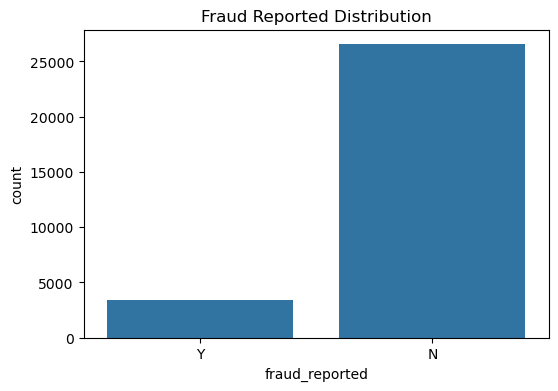

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64


In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_reported', data=df)
plt.title("Fraud Reported Distribution")
plt.show()

print(df['fraud_reported'].value_counts())

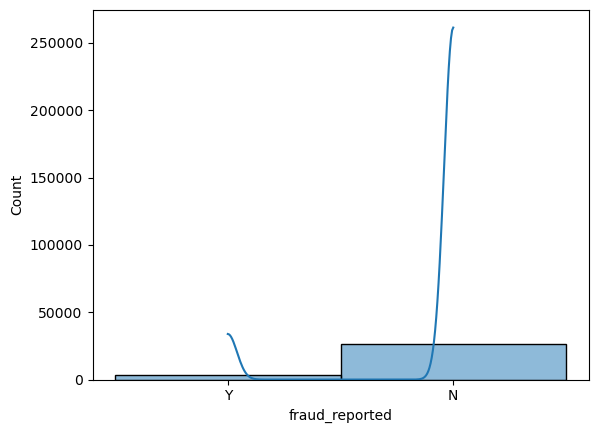

In [17]:
sns.histplot(df['fraud_reported'], kde=True)
plt.show()

In [18]:
# sepated the both  columns

In [19]:
cat_columns = df.select_dtypes(include='object').columns
num_columns = df.select_dtypes(exclude='object').columns
print(cat_columns)
print(num_columns)


Index(['policy_id', 'policy_state', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_date',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'police_report_available', 'fraud_reported'],
      dtype='object')
Index(['policy_deductible', 'policy_annual_premium', 'insured_age',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount'],
      dtype='object')


##  feature Engeneering

In [20]:
# precentage of fraudent report base on their insured age , their we saw the highest fraud found in the age 21, 22

In [21]:

gender_total = df['insured_age'].value_counts()
gender_fraud = df[df['fraud_reported'] == 1]['insured_age'].value_counts()

fraud_percentage = (gender_fraud / gender_total) * 100

print(fraud_percentage)

insured_age
18   NaN
19   NaN
20   NaN
21   NaN
22   NaN
23   NaN
24   NaN
25   NaN
26   NaN
27   NaN
28   NaN
29   NaN
30   NaN
31   NaN
32   NaN
33   NaN
34   NaN
35   NaN
36   NaN
37   NaN
38   NaN
39   NaN
40   NaN
41   NaN
42   NaN
43   NaN
44   NaN
45   NaN
46   NaN
47   NaN
48   NaN
49   NaN
50   NaN
51   NaN
52   NaN
53   NaN
54   NaN
55   NaN
56   NaN
57   NaN
58   NaN
59   NaN
60   NaN
61   NaN
62   NaN
63   NaN
64   NaN
65   NaN
66   NaN
67   NaN
68   NaN
69   NaN
70   NaN
71   NaN
72   NaN
73   NaN
74   NaN
75   NaN
Name: count, dtype: float64


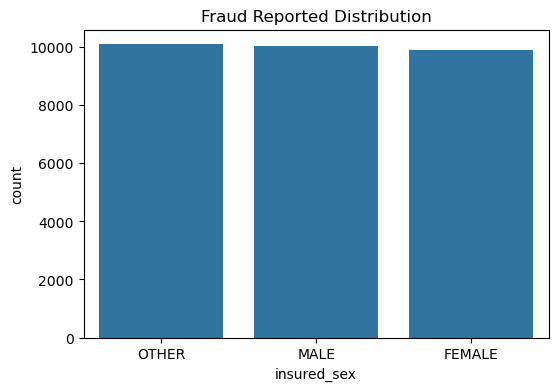

fraud_reported
N    26560
Y     3440
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='insured_sex', data=df)
plt.title("Fraud Reported Distribution")
plt.show()

print(df['fraud_reported'].value_counts())

In [23]:
# converting the categorical value to numeric 

In [24]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,0,2,400,1430.78,74,2,1,4,5,298,...,4,1470,6,1,4,0,1,8161.36,11677.60,1
1,1,8,300,854.49,74,1,0,3,1,533,...,7,5579,0,3,4,5,0,18561.79,18027.81,0
2,2,4,400,1247.28,28,2,3,1,5,601,...,4,13241,14,4,4,1,0,10734.61,10375.59,0
3,3,0,600,622.42,37,1,3,6,6,58,...,5,5562,22,3,3,5,0,13188.92,14204.34,0
4,4,4,700,1458.17,31,2,3,5,5,488,...,6,1168,18,4,2,4,0,21864.69,24038.84,0


In [26]:
# divided the data into train and test for the retio of 0:2

## Train_test_split

In [27]:
X = df.drop(['fraud_reported', 'policy_id'], axis=1)
y = df['fraud_reported']


In [28]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)


In [29]:
X_train.shape

(24000, 22)

In [30]:
y_train.shape

(24000,)

In [31]:
X_test.shape

(6000, 22)

In [32]:
y_test.shape

(6000,)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
X_train

array([[-0.17275767, -1.05057682, -0.7075491 , ..., -0.9881535 ,
         0.78605828,  1.65218174],
       [ 1.2263259 , -0.65073154, -1.18196095, ..., -0.9881535 ,
        -0.23418604, -0.61059918],
       [ 0.87655501,  0.14895903,  1.58984771, ...,  1.01198852,
         2.41050673,  1.56964346],
       ...,
       [-0.17275767, -1.05057682, -1.43499853, ...,  1.01198852,
         0.26362793,  1.48500707],
       [-0.87229946, -0.65073154,  0.75526559, ...,  1.01198852,
        -0.38328265, -0.36561232],
       [ 1.2263259 , -0.65073154,  0.85517413, ..., -0.9881535 ,
        -0.36519559, -0.11731707]], shape=(24000, 22))

In [35]:
X_test

array([[ 0.52678411,  1.74834016,  1.34745423, ...,  1.01198852,
         1.94071467,  1.73367166],
       [ 0.87655501, -1.4504221 , -0.32743554, ..., -0.9881535 ,
        -0.29692494, -0.71033293],
       [-0.87229946, -1.4504221 ,  0.50057567, ...,  1.01198852,
        -1.30880306, -1.24521658],
       ...,
       [ 0.87655501, -1.4504221 ,  0.83019699, ...,  1.01198852,
         0.17676391, -0.36804143],
       [-1.57184125,  0.54880431, -0.1560924 , ..., -0.9881535 ,
         0.29683653,  0.0828195 ],
       [-0.87229946,  0.54880431, -1.3288265 , ...,  1.01198852,
         0.41639681,  0.30625697]], shape=(6000, 22))

##  Model building

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8851666666666667
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5312
           1       0.44      0.01      0.01       688

    accuracy                           0.89      6000
   macro avg       0.67      0.50      0.48      6000
weighted avg       0.84      0.89      0.83      6000

